<a href="https://colab.research.google.com/github/FabioFavre/Pratica-6-PROCSIN/blob/main/Quest%C3%A3o_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercício 3

### Projeto de Filtro Rejeita-Faixa em Paralelo ($f_{c1}=1000$ Hz, $f_{c2}=4000$ Hz)

Um filtro rejeita-faixa pode ser construído somando a saída de um filtro passa-baixas (com $f_c = 1000$ Hz) e um filtro passa-altas (com $f_c = 4000$ Hz).

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Já temos fs, fc1, fc2 e r definidos no kernel, mas vamos garantir a função de análise
def analyze_filter(b, a, title, r_val=None):
    w, h = signal.freqz(b, a, worN=8000)
    freq = w * fs / (2 * np.pi)
    z, p, k = signal.tf2zpk(b, a)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Magnitude e Fase
    ax1.plot(freq, 20 * np.log10(np.abs(h) + 1e-9), color='b', label='Magnitude (dB)')
    ax1.set_xlabel('Frequência (Hz)')
    ax1.set_ylabel('Magnitude (dB)', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(True)

    ax1b = ax1.twinx()
    ax1b.plot(freq, np.angle(h), color='g', alpha=0.5, label='Fase (rad)')
    ax1b.set_ylabel('Fase (rad)', color='g')
    ax1b.tick_params(axis='y', labelcolor='g')
    ax1.set_title(f'{title}')

    # Polos e Zeros
    t = np.linspace(0, 2*np.pi, 100)
    ax2.plot(np.cos(t), np.sin(t), 'k--', alpha=0.5)
    ax2.scatter(np.real(z), np.imag(z), s=60, marker='o', edgecolors='b', facecolors='none', label='Zeros')
    ax2.scatter(np.real(p), np.imag(p), s=60, marker='x', color='r', label='Polos')
    ax2.set_title('Diagrama de Polos e Zeros')
    ax2.set_aspect('equal')
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

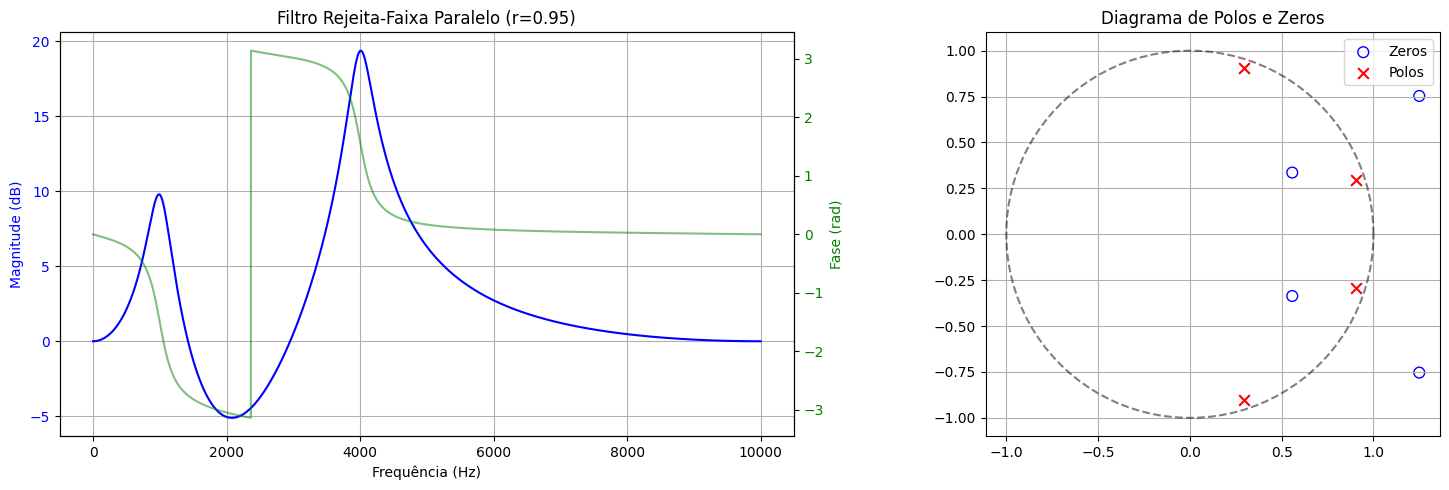

In [16]:
# 1. Bloco Passa-Baixas (1000 Hz)
theta_lp = 2 * np.pi * fc1 / fs
a_lp = [1, -2 * r * np.cos(theta_lp), r**2]
b_unit_lp = [1, 2, 1]
gain_lp = np.sum(a_lp) / np.sum(b_unit_lp)
b_lp = [x * gain_lp for x in b_unit_lp]

# 2. Bloco Passa-Altas (4000 Hz)
theta_hp = 2 * np.pi * fc2 / fs
a_hp = [1, -2 * r * np.cos(theta_hp), r**2]
b_unit_hp = [1, -2, 1]
gain_hp = np.abs(np.polyval(a_hp, -1) / np.polyval(b_unit_hp, -1))
b_hp = [x * gain_hp for x in b_unit_hp]

# Conexão Paralela: H(z) = H_lp(z) + H_hp(z)
# H(z) = (B_lp*A_hp + B_hp*A_lp) / (A_lp*A_hp)
b_parallel = np.polyadd(np.convolve(b_lp, a_hp), np.convolve(b_hp, a_lp))
a_parallel = np.convolve(a_lp, a_hp)

analyze_filter(b_parallel, a_parallel, f'Filtro Rejeita-Faixa Paralelo (r={r})')

### Comparação e Comentários

1. **Largura da Rejeição:** O filtro paralelo criado pela soma de um LP e HP resulta em uma zona de rejeição muito mais larga (entre 1000 Hz e 4000 Hz) em comparação ao filtro **Notch**, que é projetado para eliminar uma única frequência específica (frequência de entalhe).
2. **Complexidade:** O filtro paralelo é de 4ª ordem (devido à convolução de dois blocos de 2ª ordem), possuindo 4 polos e 4 zeros, enquanto o Notch padrão é de 2ª ordem.
3. **Transição:** Enquanto o Notch tem uma queda abrupta e estreita, o filtro paralelo permite definir as frequências de corte superior e inferior de forma independente, sendo mais adequado para eliminar bandas de ruído.